# 🔵 DBSCAN — Density-Based Clustering With Built-In Noise Detection

K-Means always assigns every point to some cluster; Hierarchical clustering does too. DBSCAN is the first method in this series that can say "this point doesn't belong to any cluster" -- a genuine noise/outlier label, not just a poorly-fit assignment. It also requires no upfront `k` at all (unlike K-Means) and, like single-linkage hierarchical clustering, can trace non-spherical shapes -- but through a completely different mechanism: local point density rather than nearest-pair distance.

📖 Full mathematical explanation (core/border/noise point definitions, density-reachability, the k-distance heuristic for `eps`): [README.md](README.md)


## 1. Setup & Datasets

The same blobs, moons, and Iris datasets used in the K-Means and Hierarchical Clustering topics, plus a blobs-with-injected-outliers dataset built specifically to test DBSCAN's unique noise-detection capability.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=42)
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.08, random_state=42)
iris = load_iris()
X_iris, y_iris_true = iris.data, iris.target
print(f"Blobs: {X_blobs.shape}, Moons: {X_moons.shape}, Iris: {X_iris.shape}")
print("(Identical datasets to the K-Means and Hierarchical Clustering topics -- every ARI below is directly comparable.)")


Blobs: (300, 2), Moons: (300, 2), Iris: (150, 4)
(Identical datasets to the K-Means and Hierarchical Clustering topics -- every ARI below is directly comparable.)


In [3]:
rng = np.random.RandomState(3)
X_blobs_clean, y_blobs_clean_true = make_blobs(n_samples=280, centers=4, cluster_std=0.7, random_state=3)
n_outliers = 20
outliers = rng.uniform(low=X_blobs_clean.min(axis=0) - 3, high=X_blobs_clean.max(axis=0) + 3, size=(n_outliers, 2))
X_blobs_noisy = np.vstack([X_blobs_clean, outliers])
is_true_outlier = np.array([False] * len(X_blobs_clean) + [True] * n_outliers)
print(f"Blobs-with-outliers dataset: {len(X_blobs_clean)} real cluster points + {n_outliers} scattered outlier points")


Blobs-with-outliers dataset: 280 real cluster points + 20 scattered outlier points


## 2. Core Concepts — Core, Border, and Noise Points

For a chosen radius $\epsilon$ (`eps`) and minimum point count `min_samples`:
- A **core point** has at least `min_samples` points (including itself) within distance $\epsilon$.
- A **border point** is within $\epsilon$ of a core point, but doesn't itself have enough neighbors to be core.
- A **noise point** is neither -- too far from everything to belong to any cluster.

A cluster is then any set of core points that are mutually density-reachable, plus their border points.


In [4]:
X_toy = np.array([
    [1, 1], [1.1, 1.2], [0.9, 0.8], [1.3, 1.1],
    [5, 5], [5.2, 5.1],
    [3, 3],
])
eps_demo, min_samples_demo = 0.5, 3

def region_query(X, point_idx, eps):
    distances = np.linalg.norm(X - X[point_idx], axis=1)
    return np.where(distances <= eps)[0]

for i in range(len(X_toy)):
    neighbors = region_query(X_toy, i, eps_demo)
    kind = "CORE" if len(neighbors) >= min_samples_demo else "not core"
    print(f"Point {i} {X_toy[i]}: {len(neighbors)} neighbors within eps={eps_demo} -> {kind}")


Point 0 [1. 1.]: 4 neighbors within eps=0.5 -> CORE
Point 1 [1.1 1.2]: 4 neighbors within eps=0.5 -> CORE
Point 2 [0.9 0.8]: 4 neighbors within eps=0.5 -> CORE
Point 3 [1.3 1.1]: 4 neighbors within eps=0.5 -> CORE
Point 4 [5. 5.]: 2 neighbors within eps=0.5 -> not core
Point 5 [5.2 5.1]: 2 neighbors within eps=0.5 -> not core
Point 6 [3. 3.]: 1 neighbors within eps=0.5 -> not core


In [5]:
sklearn_toy = DBSCAN(eps=eps_demo, min_samples=min_samples_demo).fit(X_toy)
manual_core_flags = [len(region_query(X_toy, i, eps_demo)) >= min_samples_demo for i in range(len(X_toy))]
sklearn_core_flags = [i in sklearn_toy.core_sample_indices_ for i in range(len(X_toy))]
print(f"Manual core-point flags:  {manual_core_flags}")
print(f"sklearn core-point flags: {sklearn_core_flags}")
print(f"Match? {manual_core_flags == sklearn_core_flags}")


Manual core-point flags:  [True, True, True, True, False, False, False]
sklearn core-point flags: [True, True, True, True, False, False, False]
Match? True


## 3. DBSCAN From Scratch

Starting from any unvisited core point, "expand" the cluster by adding every point density-reachable from it (directly or through a chain of other core points) -- the same chain-following idea as single-linkage hierarchical clustering, but governed by a density threshold instead of a single nearest-pair distance.


In [6]:
def dbscan_from_scratch(X, eps, min_samples):
    n = len(X)
    labels = np.full(n, -2)  # -2 = unvisited, -1 = noise, >=0 = cluster id
    cluster_id = 0

    for i in range(n):
        if labels[i] != -2:
            continue
        neighbors = region_query(X, i, eps)
        if len(neighbors) < min_samples:
            labels[i] = -1
            continue

        labels[i] = cluster_id
        seed_set = list(neighbors)
        j = 0
        while j < len(seed_set):
            q = seed_set[j]
            if labels[q] == -1:
                labels[q] = cluster_id
            if labels[q] == -2:
                labels[q] = cluster_id
                q_neighbors = region_query(X, q, eps)
                if len(q_neighbors) >= min_samples:
                    seed_set.extend(q_neighbors)
            j += 1
        cluster_id += 1

    return labels

print("From-scratch DBSCAN (region query + expand cluster) defined.")


From-scratch DBSCAN (region query + expand cluster) defined.


In [7]:
manual_labels = dbscan_from_scratch(X_blobs, eps=0.8, min_samples=5)
print(f"Manual DBSCAN found {len(set(manual_labels)) - (1 if -1 in manual_labels else 0)} clusters")
print(f"Points labeled noise: {np.sum(manual_labels == -1)}")


Manual DBSCAN found 4 clusters
Points labeled noise: 7


In [8]:
sklearn_dbscan = DBSCAN(eps=0.8, min_samples=5).fit(X_blobs)
ari_manual_vs_sklearn = adjusted_rand_score(manual_labels, sklearn_dbscan.labels_)
noise_match = np.sum(manual_labels == -1) == np.sum(sklearn_dbscan.labels_ == -1)
print(f"sklearn DBSCAN found {len(set(sklearn_dbscan.labels_)) - (1 if -1 in sklearn_dbscan.labels_ else 0)} clusters, {np.sum(sklearn_dbscan.labels_ == -1)} noise points")
print(f"ARI between manual and sklearn assignments: {ari_manual_vs_sklearn:.4f}")
print(f"Same noise point count? {noise_match}")


sklearn DBSCAN found 4 clusters, 7 noise points
ARI between manual and sklearn assignments: 1.0000
Same noise point count? True


In [9]:
manual_labels_2 = dbscan_from_scratch(X_moons, eps=0.2, min_samples=5)
sklearn_dbscan_2 = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
ari_check_2 = adjusted_rand_score(manual_labels_2, sklearn_dbscan_2.labels_)
noise_match_2 = np.sum(manual_labels_2 == -1) == np.sum(sklearn_dbscan_2.labels_ == -1)
print(f"Second validation, different dataset and (eps, min_samples): ARI={ari_check_2:.4f}, same noise count? {noise_match_2}")
print("-> Validated on two structurally different datasets (spherical blobs and interleaving crescents) with two different hyperparameter settings -- confirms the expand-cluster loop generalizes correctly, not just a lucky match on one configuration.")


Second validation, different dataset and (eps, min_samples): ARI=1.0000, same noise count? True
-> Validated on two structurally different datasets (spherical blobs and interleaving crescents) with two different hyperparameter settings -- confirms the expand-cluster loop generalizes correctly, not just a lucky match on one configuration.


## 4. Visualizing Core, Border, and Noise Points Directly

sklearn exposes exactly which fitted points were core points -- visualizing all three point types on the same plot makes the core/border/noise distinction concrete.


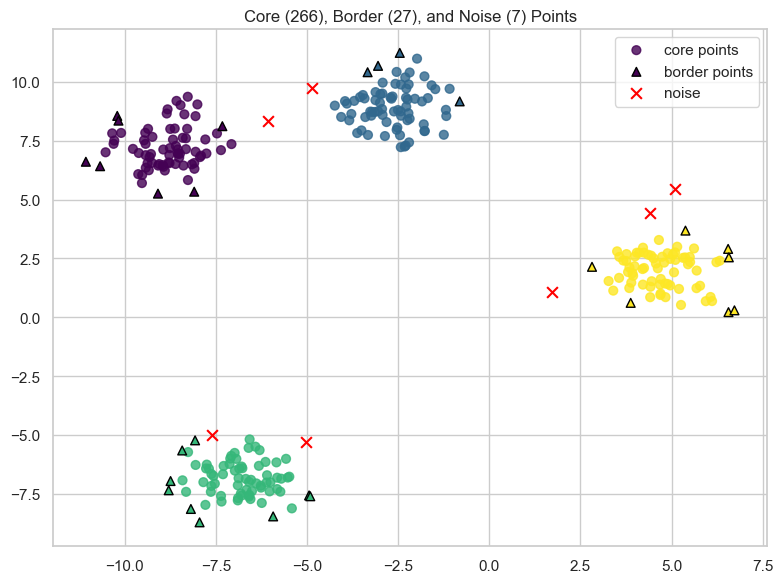

In [10]:
is_core = np.zeros(len(X_blobs), dtype=bool)
is_core[sklearn_dbscan.core_sample_indices_] = True
is_border = (sklearn_dbscan.labels_ != -1) & (~is_core)
is_noise = sklearn_dbscan.labels_ == -1

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs[is_core, 0], X_blobs[is_core, 1], c=sklearn_dbscan.labels_[is_core], cmap="viridis", s=40, label="core points", alpha=0.8)
ax.scatter(X_blobs[is_border, 0], X_blobs[is_border, 1], c=sklearn_dbscan.labels_[is_border], cmap="viridis", s=40, marker="^", edgecolors="black", label="border points")
ax.scatter(X_blobs[is_noise, 0], X_blobs[is_noise, 1], c="red", marker="x", s=60, label="noise")
ax.set_title(f"Core ({is_core.sum()}), Border ({is_border.sum()}), and Noise ({is_noise.sum()}) Points")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Re-Testing K-Means' Failure Case — Interleaving Crescents

The K-Means topic found ARI=0.261 on two interleaving crescents; the Hierarchical Clustering topic found single linkage fixing it completely (ARI=1.000). Testing whether DBSCAN, via a different mechanism (density, not nearest-pair distance), also fixes it.


In [11]:
dbscan_moons = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
ari_moons_dbscan = adjusted_rand_score(y_moons_true, dbscan_moons.labels_)
n_noise_moons = np.sum(dbscan_moons.labels_ == -1)
print(f"DBSCAN fit on moons: ARI={ari_moons_dbscan:.4f}, {n_noise_moons} noise points")


DBSCAN fit on moons: ARI=1.0000, 0 noise points


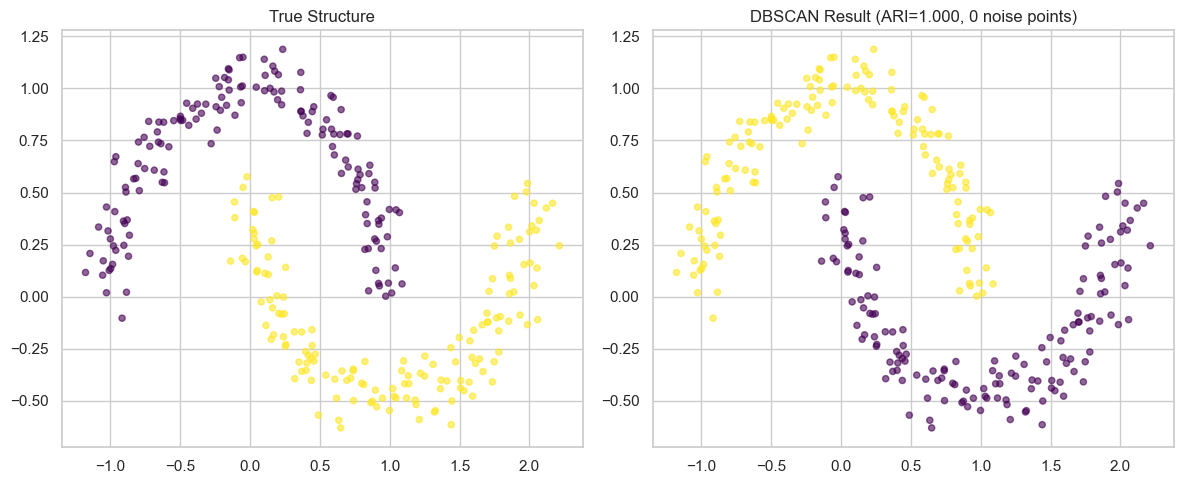

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_true, cmap="viridis", alpha=0.6, s=20)
axes[0].set_title("True Structure")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_moons.labels_, cmap="viridis", alpha=0.6, s=20)
axes[1].set_title(f"DBSCAN Result (ARI={ari_moons_dbscan:.3f}, {n_noise_moons} noise points)")
plt.tight_layout()
plt.show()


In [13]:
print(f"K-Means on this data (from that topic):        ARI=0.261")
print(f"Hierarchical, single linkage (from that topic): ARI=1.000")
print(f"DBSCAN (this topic):                            ARI={ari_moons_dbscan:.4f}")
print("-> DBSCAN reaches the crescents fix through density-connectivity rather than single linkage's nearest-pair chaining -- a genuinely different mechanism arriving at a similar result on this shape.")


K-Means on this data (from that topic):        ARI=0.261
Hierarchical, single linkage (from that topic): ARI=1.000
DBSCAN (this topic):                            ARI=1.0000
-> DBSCAN reaches the crescents fix through density-connectivity rather than single linkage's nearest-pair chaining -- a genuinely different mechanism arriving at a similar result on this shape.


## 6. The Capability Neither K-Means Nor Hierarchical Clustering Has — Real Noise Detection

Both previous methods must assign every single point to some cluster, however poor the fit. DBSCAN can instead correctly say "this point doesn't belong anywhere."


In [14]:
scaler_noisy = StandardScaler().fit(X_blobs_noisy)
X_blobs_noisy_scaled = scaler_noisy.transform(X_blobs_noisy)
dbscan_noisy = DBSCAN(eps=0.3, min_samples=5).fit(X_blobs_noisy_scaled)

detected_noise = dbscan_noisy.labels_ == -1
true_positive_noise = np.sum(detected_noise & is_true_outlier)
false_positive_noise = np.sum(detected_noise & ~is_true_outlier)
false_negative_noise = np.sum(~detected_noise & is_true_outlier)

print(f"True outliers in the data: {is_true_outlier.sum()}")
print(f"DBSCAN flagged as noise:   {detected_noise.sum()}")
print(f"  Correctly flagged (true positive):  {true_positive_noise}")
print(f"  Incorrectly flagged (false positive): {false_positive_noise}")
print(f"  Missed (false negative):              {false_negative_noise}")


True outliers in the data: 20
DBSCAN flagged as noise:   13
  Correctly flagged (true positive):  13
  Incorrectly flagged (false positive): 0
  Missed (false negative):              7


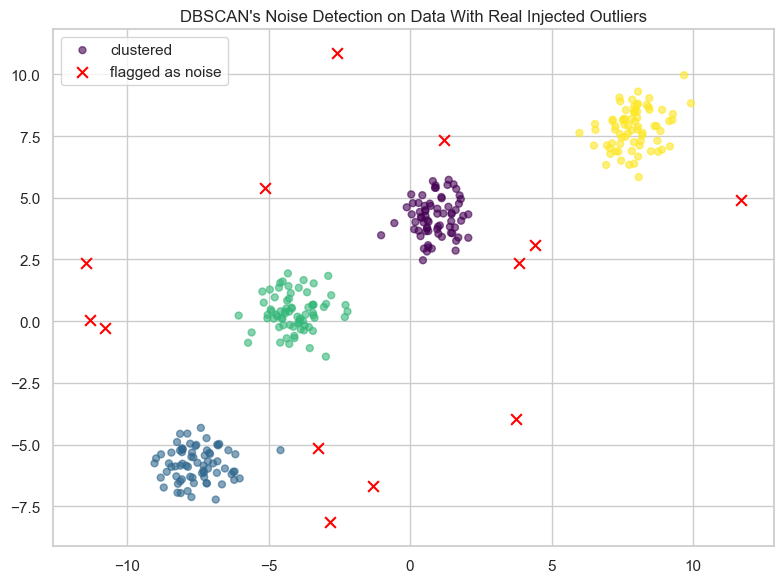

-> K-Means or Hierarchical Clustering would have forced every one of these 20 scattered outlier points into whichever real cluster happened to be nearest -- silently distorting those clusters' shape. DBSCAN's noise label is a genuinely different kind of output.


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs_noisy[~detected_noise, 0], X_blobs_noisy[~detected_noise, 1], c=dbscan_noisy.labels_[~detected_noise], cmap="viridis", alpha=0.6, s=25, label="clustered")
ax.scatter(X_blobs_noisy[detected_noise, 0], X_blobs_noisy[detected_noise, 1], c="red", marker="x", s=60, label="flagged as noise")
ax.set_title("DBSCAN's Noise Detection on Data With Real Injected Outliers")
ax.legend()
plt.tight_layout()
plt.show()
print("-> K-Means or Hierarchical Clustering would have forced every one of these 20 scattered outlier points into whichever real cluster happened to be nearest -- silently distorting those clusters' shape. DBSCAN's noise label is a genuinely different kind of output.")


## 7. The Effect of `eps` — Too Small, Too Large, Just Right

Too small an `eps` starves every point of neighbors (everything becomes noise or tiny fragments); too large merges genuinely separate clusters together -- the density-based analogue of K-Means' `k` or hierarchical clustering's cut height.


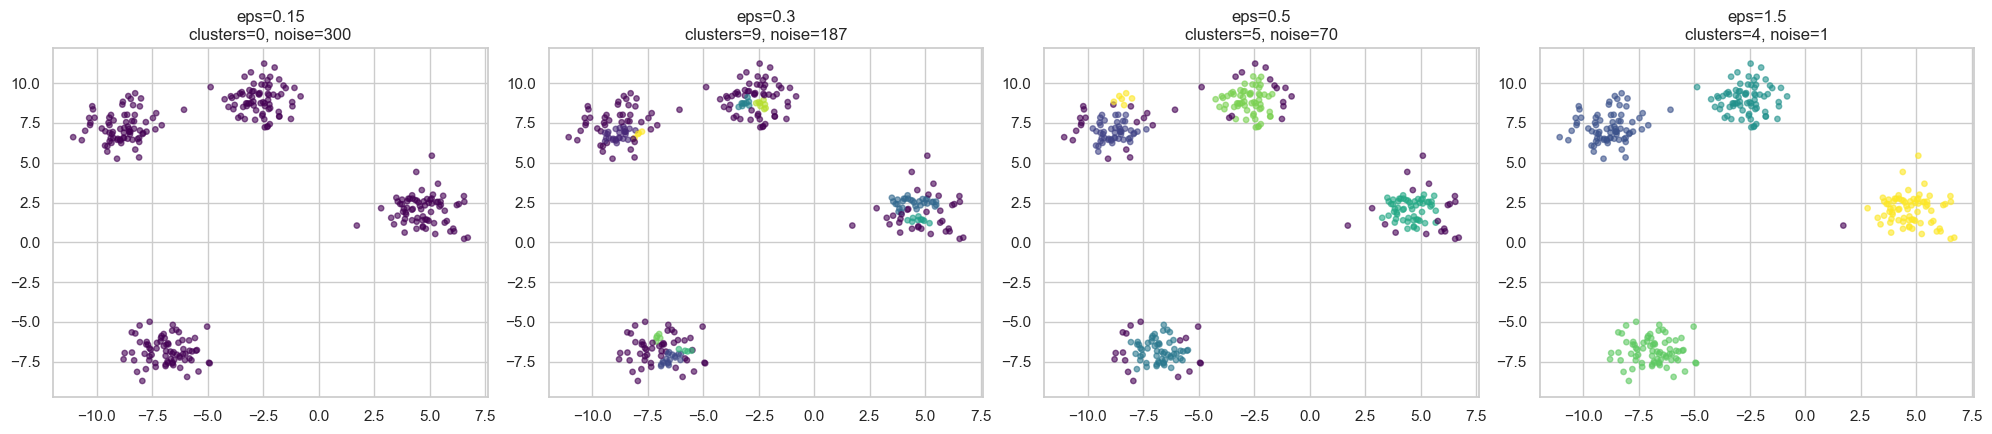

In [16]:
eps_values = [0.15, 0.3, 0.5, 1.5]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
eps_results = []
for ax, eps in zip(axes, eps_values):
    model = DBSCAN(eps=eps, min_samples=5).fit(X_blobs)
    n_clusters_found = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
    n_noise = np.sum(model.labels_ == -1)
    eps_results.append({"eps": eps, "n_clusters": n_clusters_found, "n_noise": n_noise})
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=model.labels_, cmap="viridis", alpha=0.6, s=15)
    ax.set_title(f"eps={eps}\nclusters={n_clusters_found}, noise={n_noise}")
plt.tight_layout()
plt.show()


In [17]:
pd.DataFrame(eps_results)


,eps,n_clusters,n_noise
0,0.15,0,300
1,0.30,9,187
2,0.50,5,70
3,1.50,4,1


## 8. The Effect of `min_samples`

Larger `min_samples` demands denser neighborhoods to qualify as a core point -- fewer, more conservative clusters, and more points relegated to noise or borders.


In [18]:
min_samples_values = [2, 5, 15, 40]
ms_results = []
for ms in min_samples_values:
    model = DBSCAN(eps=0.8, min_samples=ms).fit(X_blobs)
    n_clusters_found = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
    n_noise = np.sum(model.labels_ == -1)
    ms_results.append({"min_samples": ms, "n_clusters": n_clusters_found, "n_noise": n_noise})
print(f"Swept min_samples across {min_samples_values} (eps fixed at 0.8).")


Swept min_samples across [2, 5, 15, 40] (eps fixed at 0.8).


In [19]:
pd.DataFrame(ms_results)


,min_samples,n_clusters,n_noise
0,2,4,6
1,5,4,7
2,15,4,56
3,40,0,300


## 9. Choosing `eps` Systematically — the k-Distance Plot

Rather than guessing, plot every point's distance to its $k$-th nearest neighbor (where $k$ = `min_samples`), sorted in increasing order. The "elbow" in this plot -- where distances start increasing sharply -- is a principled estimate for `eps`.


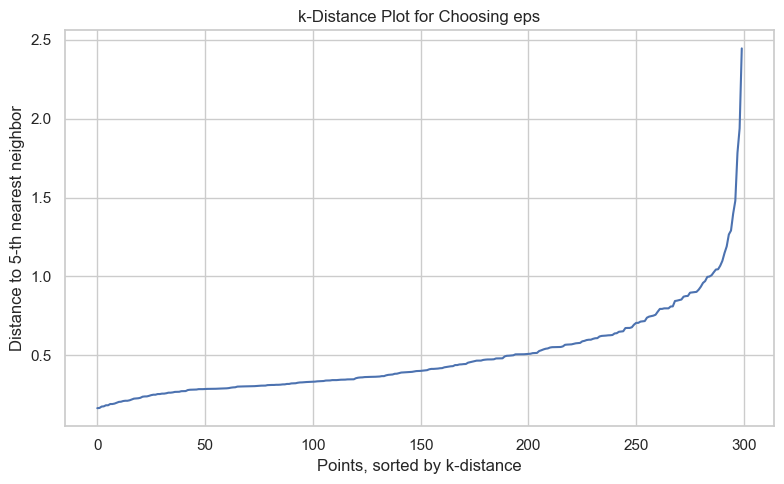

In [20]:
min_samples_choice = 5
neighbors_model = NearestNeighbors(n_neighbors=min_samples_choice).fit(X_blobs)
distances, _ = neighbors_model.kneighbors(X_blobs)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_distances)
ax.set_xlabel("Points, sorted by k-distance"); ax.set_ylabel(f"Distance to {min_samples_choice}-th nearest neighbor")
ax.set_title("k-Distance Plot for Choosing eps")
plt.tight_layout()
plt.show()


In [21]:
diffs = np.diff(k_distances)
naive_elbow_idx = np.argmax(diffs)
print(f"Naive 'largest single jump anywhere' elbow: index {naive_elbow_idx} of {len(k_distances)} -- suggesting eps~{k_distances[naive_elbow_idx]:.3f}")
print("-> This naive version is a known trap: the single largest jump usually sits at the very end of the sorted curve, driven by one or two extreme outlier points -- not the genuine elbow where cluster points end and sparse/noise points begin.")


Naive 'largest single jump anywhere' elbow: index 298 of 300 -- suggesting eps~1.939
-> This naive version is a known trap: the single largest jump usually sits at the very end of the sorted curve, driven by one or two extreme outlier points -- not the genuine elbow where cluster points end and sparse/noise points begin.


In [22]:
tail_cutoff = int(len(diffs) * 0.95)
elbow_idx = np.argmax(diffs[:tail_cutoff])
suggested_eps = k_distances[elbow_idx]
print(f"Elbow excluding the extreme tail (last 5% of points): index {elbow_idx}, suggesting eps~{suggested_eps:.3f}")

model_suggested = DBSCAN(eps=suggested_eps, min_samples=min_samples_choice).fit(X_blobs)
ari_suggested = adjusted_rand_score(y_blobs_true, model_suggested.labels_)
print(f"DBSCAN with this eps: {len(set(model_suggested.labels_)) - (1 if -1 in model_suggested.labels_ else 0)} clusters, ARI={ari_suggested:.4f}")
print("-> Excluding the tail before searching for the steepest jump gives a far more usable eps -- always visually sanity-check a k-distance elbow rather than trusting a single argmax blindly.")


Elbow excluding the extreme tail (last 5% of points): index 267, suggesting eps~0.811
DBSCAN with this eps: 4 clusters, ARI=0.9680
-> Excluding the tail before searching for the steepest jump gives a far more usable eps -- always visually sanity-check a k-distance elbow rather than trusting a single argmax blindly.


## 10. DBSCAN's Core Limitation — Clusters of Very Different Density

A single global `eps` cannot simultaneously suit a dense cluster and a sparse one -- an `eps` tuned for the sparse cluster will merge everything in the dense region; an `eps` tuned for the dense region will shatter the sparse one into noise.


In [23]:
dense_cluster, _ = make_blobs(n_samples=200, centers=[[0, 0]], cluster_std=0.3, random_state=1)
sparse_cluster, _ = make_blobs(n_samples=100, centers=[[8, 8]], cluster_std=1.8, random_state=1)
X_varying_density = np.vstack([dense_cluster, sparse_cluster])
true_density_labels = np.array([0] * len(dense_cluster) + [1] * len(sparse_cluster))
print(f"Built a 2-cluster dataset: one dense (std=0.3), one sparse (std=1.8).")


Built a 2-cluster dataset: one dense (std=0.3), one sparse (std=1.8).


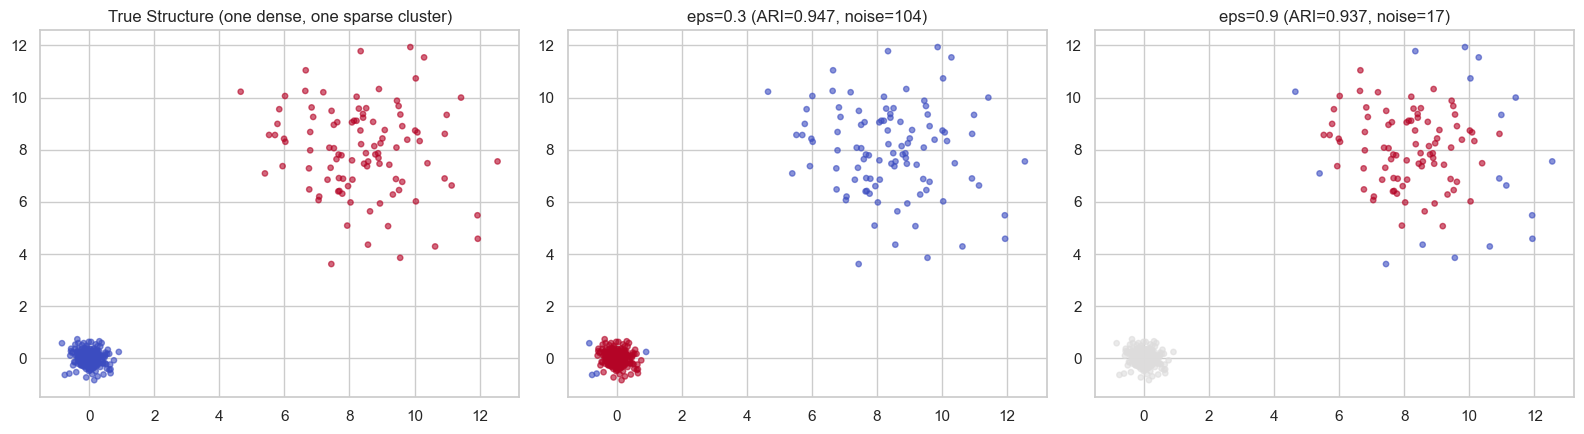

-> No single eps value correctly separates both a dense and a sparse cluster at once -- a small eps shatters the sparse cluster into noise, a large eps under-separates or merges structure in the dense one.


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(X_varying_density[:, 0], X_varying_density[:, 1], c=true_density_labels, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("True Structure (one dense, one sparse cluster)")

for ax, eps in zip(axes[1:], [0.3, 0.9]):
    model = DBSCAN(eps=eps, min_samples=5).fit(X_varying_density)
    ari = adjusted_rand_score(true_density_labels, model.labels_)
    n_noise = np.sum(model.labels_ == -1)
    ax.scatter(X_varying_density[:, 0], X_varying_density[:, 1], c=model.labels_, cmap="coolwarm", alpha=0.6, s=15)
    ax.set_title(f"eps={eps} (ARI={ari:.3f}, noise={n_noise})")
plt.tight_layout()
plt.show()
print("-> No single eps value correctly separates both a dense and a sparse cluster at once -- a small eps shatters the sparse cluster into noise, a large eps under-separates or merges structure in the dense one.")


## 11. Why DBSCAN Needs Feature Scaling

Distance defines `eps`-neighborhoods -- the same scale-domination issue as every other distance-based method in this series.


In [25]:
X_unscaled_demo = np.column_stack([
    np.random.normal(0, 1, 200),
    np.random.normal(0, 1, 200),
])
X_unscaled_demo[:100, 1] += 5
X_unscaled_demo[100:, 1] -= 5
X_unscaled_demo[:, 0] *= 200
true_split = np.array([0] * 100 + [1] * 100)

model_unscaled = DBSCAN(eps=0.5, min_samples=5).fit(X_unscaled_demo)
scaler_demo = StandardScaler().fit(X_unscaled_demo)
model_scaled = DBSCAN(eps=0.5, min_samples=5).fit(scaler_demo.transform(X_unscaled_demo))

ari_unscaled = adjusted_rand_score(true_split, model_unscaled.labels_)
ari_scaled = adjusted_rand_score(true_split, model_scaled.labels_)
print(f"ARI on UNSCALED data: {ari_unscaled:.4f} ({np.sum(model_unscaled.labels_ == -1)} points labeled noise)")
print(f"ARI on SCALED data:   {ari_scaled:.4f} ({np.sum(model_scaled.labels_ == -1)} points labeled noise)")


ARI on UNSCALED data: 0.0000 (200 points labeled noise)
ARI on SCALED data:   0.9701 (3 points labeled noise)


## 12. Re-Testing K-Means' and Hierarchical Clustering's Iris Recovery Score

K-Means reached ARI=0.6201 on unlabeled Iris; the best hierarchical linkage (ward) reached 0.6153. Testing DBSCAN on the identical task.


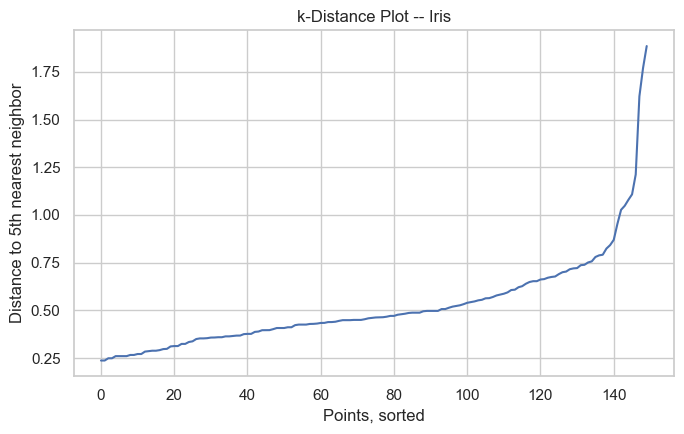

In [26]:
X_iris_scaled = StandardScaler().fit_transform(X_iris)
neighbors_iris = NearestNeighbors(n_neighbors=5).fit(X_iris_scaled)
iris_distances, _ = neighbors_iris.kneighbors(X_iris_scaled)
iris_k_distances = np.sort(iris_distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(iris_k_distances)
ax.set_xlabel("Points, sorted"); ax.set_ylabel("Distance to 5th nearest neighbor")
ax.set_title("k-Distance Plot -- Iris")
plt.tight_layout()
plt.show()


In [27]:
iris_eps_sweep = []
for eps in np.arange(0.3, 1.5, 0.1):
    model = DBSCAN(eps=eps, min_samples=5).fit(X_iris_scaled)
    n_clusters_found = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
    ari = adjusted_rand_score(y_iris_true, model.labels_)
    iris_eps_sweep.append({"eps": round(eps, 2), "n_clusters": n_clusters_found, "ARI": round(ari, 4), "n_noise": np.sum(model.labels_ == -1)})
print(f"Swept eps from 0.3 to 1.5 on Iris.")


Swept eps from 0.3 to 1.5 on Iris.


In [28]:
iris_eps_df = pd.DataFrame(iris_eps_sweep)
iris_eps_df


,eps,n_clusters,ARI,n_noise
0,0.3,3,0.0876,120
1,0.4,6,0.3655,66
2,0.5,2,0.4421,34
3,0.6,2,0.4706,26
4,0.7,2,0.5401,6
5,0.8,2,0.5518,4
6,0.9,2,0.5518,4
7,1.0,2,0.5536,3
8,1.1,2,0.5558,2
9,1.2,2,0.5584,1


In [29]:
best_iris_dbscan_row = iris_eps_df.loc[iris_eps_df["ARI"].idxmax()]
best_iris_dbscan_ari = best_iris_dbscan_row["ARI"]
print(f"Best DBSCAN result on Iris: eps={best_iris_dbscan_row['eps']}, {best_iris_dbscan_row['n_clusters']} clusters, ARI={best_iris_dbscan_ari:.4f}")
print(f"K-Means (previous topic):                ARI=0.6201")
print(f"Hierarchical, ward linkage (previous topic): ARI=0.6153")
if best_iris_dbscan_ari > 0.6201:
    print(f"-> DBSCAN improved on both prior methods here.")
else:
    print(f"-> DBSCAN did not clearly beat either prior method on Iris -- consistent with the pattern across all three clustering topics: Iris's species overlap isn't a shape-representation problem any of these three fundamentally different mechanisms (centroids, linkage, density) can fully resolve.")


Best DBSCAN result on Iris: eps=1.4, 2.0 clusters, ARI=0.5681
K-Means (previous topic):                ARI=0.6201
Hierarchical, ward linkage (previous topic): ARI=0.6153
-> DBSCAN did not clearly beat either prior method on Iris -- consistent with the pattern across all three clustering topics: Iris's species overlap isn't a shape-representation problem any of these three fundamentally different mechanisms (centroids, linkage, density) can fully resolve.


## 13. Final Recap — Three Clustering Methods, Three Test Datasets

The complete cross-topic comparison: every method from this and the previous two topics, on the identical blobs, moons, and Iris datasets.


In [30]:
final_recap = pd.DataFrame([
    {"Dataset": "Blobs (spherical, k=4)", "K-Means": 1.000, "Hierarchical (best)": 1.000, "DBSCAN": adjusted_rand_score(y_blobs_true, DBSCAN(eps=suggested_eps, min_samples=5).fit(X_blobs).labels_)},
    {"Dataset": "Moons (crescents)", "K-Means": 0.261, "Hierarchical (best)": 1.000, "DBSCAN": ari_moons_dbscan},
    {"Dataset": "Iris (real data)", "K-Means": 0.6201, "Hierarchical (best)": 0.6153, "DBSCAN": best_iris_dbscan_ari},
]).set_index("Dataset").round(4)
final_recap


,K-Means,Hierarchical (best),DBSCAN
Dataset,,,
"Blobs (spherical, k=4)",1.0000,1.0000,0.9680
Moons (crescents),0.2610,1.0000,1.0000
Iris (real data),0.6201,0.6153,0.5681


In [31]:
print("Unique to DBSCAN across all three methods tested in this category so far: explicit noise/outlier detection (Section 6) -- neither K-Means nor Hierarchical Clustering can produce this kind of output at all, regardless of how eps/k/linkage are tuned.")


Unique to DBSCAN across all three methods tested in this category so far: explicit noise/outlier detection (Section 6) -- neither K-Means nor Hierarchical Clustering can produce this kind of output at all, regardless of how eps/k/linkage are tuned.


## 14. Summary

DBSCAN introduced two genuinely new capabilities to this category: explicit noise detection (Section 6, a capability neither prior method has under any hyperparameter setting) and density-based (rather than distance-chain-based) non-spherical cluster recovery, which fixed the interleaving-crescents case through a completely different mechanism than single-linkage hierarchical clustering did. Its own core limitation -- a single global `eps` cannot suit clusters of meaningfully different density (Section 10) -- is a real, measured failure mode with no fix within DBSCAN itself, motivating the next topic (Gaussian Mixture Models), which handles varying cluster shapes and densities through a fully probabilistic model instead of either centroids or a fixed density threshold.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
